In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np
import mpltern 
import torch
from funcshape.networks import CurveReparametrizer
from funcshape.layers.sineseries import SineSeries
from funcshape.loss import CurveDistance
from funcshape.logging import Logger
from funcshape.reparametrize import reparametrize
from funcshape.utils import col_linspace
from funcshape.visual import plot_curve 
from funcshape.transforms import SRVT
from funcshape.curve import ParametricCurve
from funcshape.interpolation import linear_interpolate, geodesic

In [2]:
data_dir = "/Users/knv2/Documents/codebase/labeler_sweeps/phase_data"

In [3]:
ref = xr.load_dataset(data_dir+"/pm-0.0-1275.nc")
query = xr.load_dataset(data_dir+"/pm-0.0-325.nc")

In [4]:
def extract_boundaries_mpltern(domain, labels):
    """
    Extract boundary contour lines (in barycentric coordinates) for each phase
    label from a discrete ternary phase map. Uses Matplotlib's tricontour
    internally without displaying plots.

    Parameters
    ----------
    domain : (N, 3) ndarray
        Array of barycentric coordinates (t, l, r) of sampling points.
        Each row must satisfy t + l + r = 1.
    labels : (N,) ndarray
        Array of integer labels assigning a phase to each domain point.

    Returns
    -------
    boundaries : dict
        Dictionary mapping each unique phase label to a list of arrays.
        Each array has shape (M, 3) and contains the barycentric (t, l, r)
        coordinates of a contour segment (boundary) for that phase.

    Notes
    -----
    - Each phase may have multiple disconnected boundary segments, so the
      return value for a label is a list of arrays.
    - Contours are extracted at level 0 from a binary mask where the phase
      is assigned +1 and all others -1.
    - This function creates temporary Matplotlib figures internally but
      closes them immediately to avoid displaying plots.
    """
    boundaries = {}
    for phase in np.unique(labels):
        masked_codomain = np.where(labels == phase, 1.0, -1.0)

        fig, axs = plt.subplots(
            1,2, 
            figsize=(4*2, 4), 
            subplot_kw={"projection":"ternary"}
        )
        ax = axs[0]
        ax.scatter(
            domain[:,0], 
            domain[:,1], 
            domain[:,2],
            s = 5,
            color="k"
        )
        cs = ax.tricontour(
            domain[:,0], 
            domain[:,1], 
            domain[:,2],
            masked_codomain, 
            levels=[0.0],
            color = "w"
        )
        vertices = []
        for polygon in cs.allsegs[0]: # should be only single level at 0.0
            for vertex in polygon:
                coords = ax.transProjection.inverted().transform(vertex)
                vertices.append(coords)
        boundaries[str(phase)] = np.asarray(vertices).squeeze()

        ax = axs[1]
        ax.scatter(
            boundaries[str(phase)][:,0], 
            boundaries[str(phase)][:,1], 
            boundaries[str(phase)][:,2],
            s=10,
            label = phase
        )

        plt.close(fig)  # avoid showing the figure

    return boundaries

In [5]:
ref_boundaries = extract_boundaries_mpltern(ref["compositions"].values, ref["labels"].values)
query_boundaries = extract_boundaries_mpltern(query["compositions"].values, query["labels"].values)

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/mpltern/_ternary_parsers.py:42: UserWarning: The following kwargs were not used by contour: 'color'
  return f(ax, *args, **kwargs)


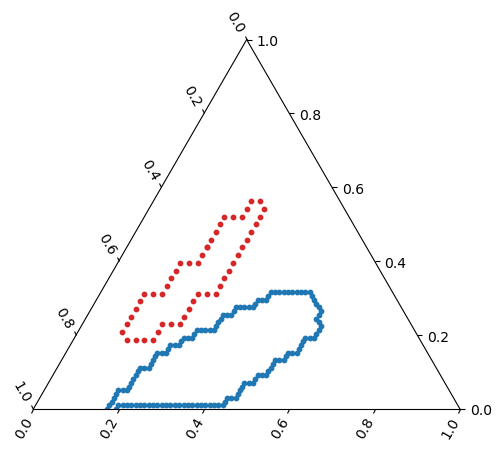

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection":"ternary"})
ax.scatter(
    ref_boundaries["La"][:,0], 
    ref_boundaries["La"][:,1], 
    ref_boundaries["La"][:,2],
    s=10,
    color = "tab:blue"
)
ref_xy = ax.transProjection.transform(ref_boundaries["La"])
ax.scatter(
    query_boundaries["H2"][:,0], 
    query_boundaries["H2"][:,1], 
    query_boundaries["H2"][:,2],
    s=10,
    color = "tab:red"
)
query_xy = ax.transProjection.transform(query_boundaries["H2"])
plt.show()

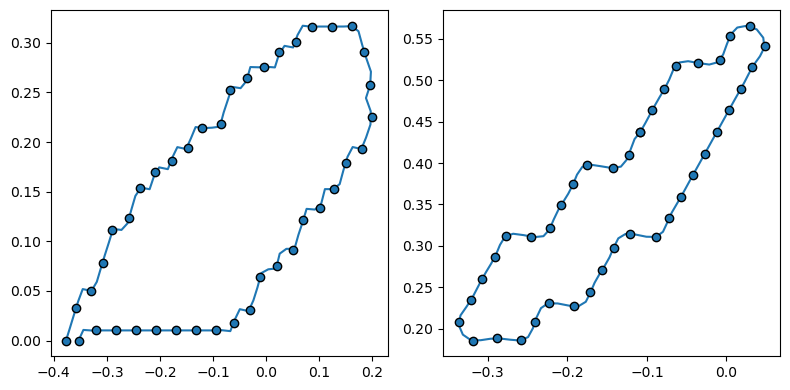

In [7]:
c1 = ParametricCurve(ref_xy)
c2 = ParametricCurve(query_xy)

# Plot curves
fig, axs = plt.subplots(1,2, figsize=(8, 4))
plot_curve(c1, npoints=100, dotpoints=41, ax=axs[0])
plot_curve(c2, npoints=100, dotpoints=41, ax=axs[1])
plt.tight_layout()
plt.show()

[Iter     1] loss: 3.176158
[Iter     2] loss: 3.176158
Finished training in 0.07775s


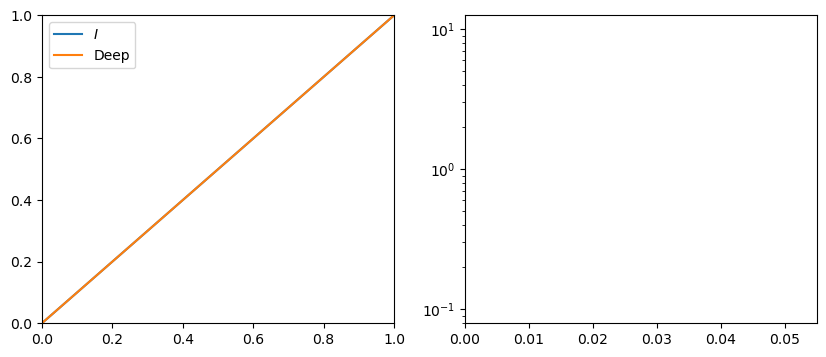

In [8]:
q = SRVT(c1)
r = SRVT(c2)

n = 15  # Number of basis functions in layer
k = 1024  # Number of points used for evaluation.
ell = 10 # Number of layers used to approximate \phi
# Deep reparametrization
loss = CurveDistance(q, r, k=k)
RN = CurveReparametrizer([
    SineSeries(n) for _ in range(ell)
])
opt = torch.optim.LBFGS(
    RN.parameters(), 
    line_search_fn='strong_wolfe', 
    max_iter=300, 
    max_eval=300,
    history_size=300,
)
error_deep = reparametrize(RN, loss, opt, 300, Logger(1))
RN.detach()
x = col_linspace(0, 1, k)
y_deep = RN(x)

# Plot diffeomorphism and subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, x, label=r"$I$")
ax1.plot(x, y_deep, label="Deep")
# ax1.plot(x, g(x), 'k--', label=r'$ \varphi $')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend()
ax2.semilogy(error_deep / error_deep[0])
ax2.set_xlim(0, None)
plt.show()

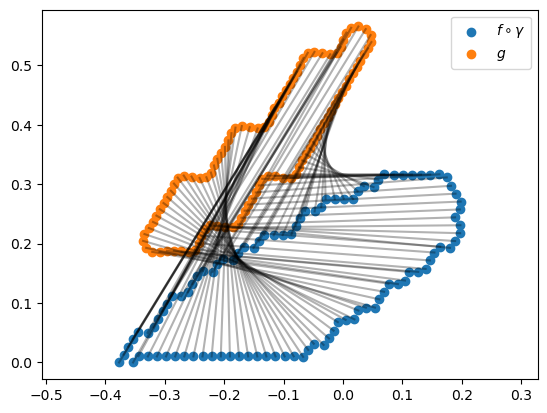

In [9]:
fig, ax = plt.subplots()
xlin = col_linspace(0, 1, 100)
c1_ = c1(RN(xlin))
c2_ = c2(xlin)
ax.scatter(c1_[:,0], c1_[:,1], label=r"$ f \circ \gamma$")
ax.scatter(c2_[:,0], c2_[:,1], label=r"$g$")
for p1, p2 in zip(c1_, c2_):
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "k-", alpha=0.3)
ax.legend()
ax.axis("equal")
plt.show()

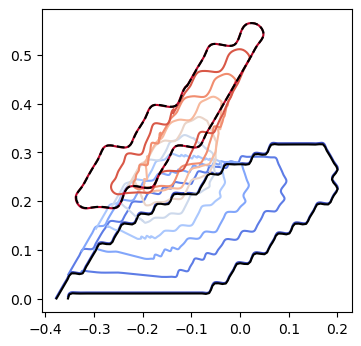

In [10]:
# Interpolate
numsteps=10
rafter = r.compose(RN)
srvts = geodesic(q, rafter, steps=numsteps)
colors = plt.get_cmap("coolwarm")(np.linspace(0,1,numsteps))

fig, ax = plt.subplots(figsize=(4, 4))
starts = [(1.0-t)*c1(torch.Tensor([0.0])) + t*c2(torch.Tensor([0.0])) for t in np.linspace(0,1, numsteps)]
[plot_curve(lambda x: ci(x)+start, ax=ax, color=colori, npoints=601) for ci, colori, start in zip(srvts, colors, starts)]
plot_curve(c1, ax=ax, color="k")
plot_curve(c2, ax=ax, color="k", ls='--')
ax.set_aspect("equal")

plt.show()

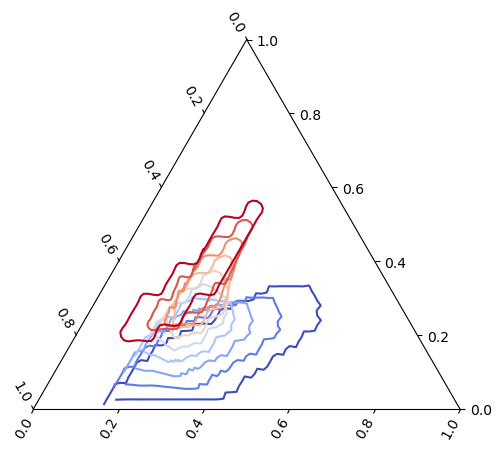

In [11]:
fig, ax = plt.subplots(subplot_kw={"projection":"ternary"})
for i in range(numsteps):
    ci = srvts[i](xlin)+starts[i]
    ci_bary = ax.transProjection.inverted().transform(ci)
    ax.plot(
        ci_bary[:,0], 
        ci_bary[:,1], 
        ci_bary[:,2],
        color = colors[i]
    )
plt.show()

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Setup ---
numsteps = 10
xlin = col_linspace(0, 1, 100)
rafter = r.compose(RN)
srvts = geodesic(q, rafter, steps=numsteps)
colors = plt.get_cmap("coolwarm")(np.linspace(0,1,numsteps))

# compute shifts for each step
starts = [(1.0-t)*c1(torch.Tensor([0.0])) + t*c2(torch.Tensor([0.0])) for t in np.linspace(0,1,numsteps)]

# --- Precompute barycentric coordinates for all curves ---
curves_bary = []
for i in range(numsteps):
    ci = srvts[i](xlin) + starts[i]
    ci_bary = ax.transProjection.inverted().transform(ci.detach().cpu().numpy())
    curves_bary.append(ci_bary)

# --- Setup figure and axis ---
fig, ax = plt.subplots(subplot_kw={"projection": "ternary"}, figsize=(6,6))

def init():
    ax.clear()
    ax.set_title("Geodesic evolution in ternary space")
    return []

def update(frame):
    ax.clear()
    ax.set_title(f"Geodesic evolution (t={frame}/{numsteps-1})")
    
    # Plot all past curves as faint grey shadows
    for j in range(frame):
        ax.plot(
            curves_bary[j][:,0],
            curves_bary[j][:,1],
            curves_bary[j][:,2],
            color="grey",
            alpha=0.25,
            linewidth=2.0
        )

    # Plot current curve in color
    ax.plot(
        curves_bary[frame][:,0],
        curves_bary[frame][:,1],
        curves_bary[frame][:,2],
        color=colors[frame],
        linewidth=2.0
    )

    # Always plot start and end curves in fixed colors
    ax.plot(
        curves_bary[0][:,0],
        curves_bary[0][:,1],
        curves_bary[0][:,2],
        color="tab:blue",
        linewidth=2.5,
        label="Start",
        alpha=0.25
    )
    ax.plot(
        curves_bary[-1][:,0],
        curves_bary[-1][:,1],
        curves_bary[-1][:,2],
        color="tab:orange",
        linewidth=2.5,
        label="End",
        alpha=0.25
    )

    return []

# --- Animate ---
anim = FuncAnimation(
    fig, update, frames=range(numsteps), init_func=init, blit=False
)

# --- Save as GIF ---
anim.save("geodesic_evolution.gif", writer=PillowWriter(fps=2))
plt.close(fig)